In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import json
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path
import sys
import pandas as pd

import cogwheel.cosmology
import cogwheel.data
import cogwheel.posterior
import cogwheel.sampling
import cogwheel.gw_plotting
import cogwheel.gw_utils
from cogwheel.likelihood.marginalization.coherent_score_lensing import bayes_factor_p_lensed, \
                                                                        get_bayes_factor_of_samples, \
                                                                        bootstrap_bayes_factors

import gwosc
import gwpy.table
from pesummary.io import read

import warnings
warnings.simplefilter("ignore", RuntimeWarning)

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
from parameter_estimation import load_posterior_samples, add_derived_quantities
from pe_injections import chirp_mass

In [2]:
def get_posterior_samples(event_data, eventdir, plot=True, pars_to_plot=['m1', 'm2', 'iota']):

    # load the posterior samples
    samples = load_posterior_samples(eventname, eventdir)
    # add derived quantities
    add_derived_quantities(samples)

    if plot:
        # injected parameters
        injected_par_dict = event_data.get_init_dict()['injection']['par_dic']
        # add derived quantities
        injected_par_dict['mchirp'] = chirp_mass(injected_par_dict['m1'], injected_par_dict['m2'])
        injected_par_dict['chieff'] = cogwheel.gw_utils.chieff(injected_par_dict['m1'], injected_par_dict['m2'],
                                                                injected_par_dict['s1z'], injected_par_dict['s2z'])
        # injected parameters to plot
        # get the subset of the data release posterior parameters
        injected_pars_to_plot = {}
        for key, value in injected_par_dict.items():
            if key in pars_to_plot:
                injected_pars_to_plot[key] = value

        # plot parameters for our cogwheel results:
        plot_params = pars_to_plot.copy()
        plot_params.append('p_lensed')
        
        # corner this guy
        corner_plot = cogwheel.gw_plotting.CornerPlot(
            samples, params=plot_params, tail_probability=1e-4, color_2d='royalblue',
            kwargs_1d=dict(color='royalblue', alpha=0.8), contour_kwargs=dict(alpha=0.8)
        )
        corner_plot.plot(max_figsize=5)
        corner_plot.scatter_points(injected_pars_to_plot, colors=['#FF5C5C'], s=150,
                                    zorder=2, marker='+', adjust_lims=True)

    return samples

In [3]:
# load injection results
mchirp = 30.    # Msun

# construct the grid
iota_grid = np.array([0., 0.2, 0.4, 0.5, 1.]) * np.pi
q_grid = np.arange(0.1, 1.01, 0.1)

seed = 12
prior_class = 'IntrinsicLVCPrior'

# load our posterior samples and the released samples from the LVK PE
resdir = f'/home/abbye.williams/GWPE/data/pe_runs_lensing/injections/iota_q_grid/mchirp-{mchirp:.2f}/{prior_class}'

# Bayes factor
n_resamples = 1000  # number of resamples for Bayes factor bootstrap
lnBayes = {}

for i, iota in enumerate(iota_grid):
    for j, q in enumerate(q_grid):

        # event file
        eventname = f'GW{seed}_iota-{iota / np.pi:.2f}_q-{q:.2f}'
        eventdir = os.path.join(resdir, eventname, 'run_0')
        fn = os.path.join(eventdir, f'{eventname}.npz')

        # load event data
        try:
            event_data = cogwheel.data.EventData.from_npz(filename=fn)
            try:
                samples = get_posterior_samples(event_data, os.path.join(resdir, eventname), plot=False)
            except TypeError:
                lnBayes[(iota, q)] = (np.nan, np.nan)
                continue
        except FileNotFoundError:
            lnBayes[(iota, q)] = (np.nan, np.nan)
            continue

        # Bayes factors
        bayes_factors = bootstrap_bayes_factors(samples, n_resamples)
        # log these
        lnbayes_factors = np.log(bayes_factors)
        # get the median and standard deviation
        lnbayes, lnbayes_std = np.median(lnbayes_factors), np.std(lnbayes_factors)
        lnBayes[(iota, q)] = (lnbayes, lnbayes_std)

loaded posterior samples for GW12_iota-0.00_q-0.10 run 0
loaded posterior samples for GW12_iota-0.00_q-0.20 run 0
loaded posterior samples for GW12_iota-0.00_q-0.30 run 0
loaded posterior samples for GW12_iota-0.00_q-0.40 run 0
loaded posterior samples for GW12_iota-0.00_q-0.50 run 0
loaded posterior samples for GW12_iota-0.00_q-0.60 run 0
loaded posterior samples for GW12_iota-0.00_q-0.70 run 0
loaded posterior samples for GW12_iota-0.00_q-0.80 run 1
loaded posterior samples for GW12_iota-0.00_q-0.90 run 0
loaded posterior samples for GW12_iota-0.00_q-1.00 run 0
loaded posterior samples for GW12_iota-0.20_q-0.10 run 0
loaded posterior samples for GW12_iota-0.20_q-0.20 run 0
loaded posterior samples for GW12_iota-0.20_q-0.30 run 0
loaded posterior samples for GW12_iota-0.20_q-0.40 run 0
loaded posterior samples for GW12_iota-0.20_q-0.50 run 0
loaded posterior samples for GW12_iota-0.20_q-0.60 run 0
loaded posterior samples for GW12_iota-0.20_q-0.70 run 0
loaded posterior samples for GW

In [4]:
# plot the Bayes factors
# reformat into a 2D array
lnBayes_grid = np.full((len(iota_grid), len(q_grid)), np.nan)
for i, iota in enumerate(iota_grid):
    for j, q in enumerate(q_grid):
        lnBayes_grid[i,j] = lnBayes[(iota, q)][0]

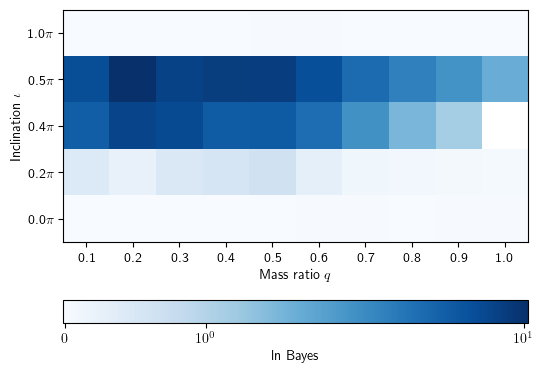

In [5]:
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(lnBayes_grid, origin='lower', cmap='Blues', norm='symlog')
q_grid_str = [
    f'{x:.1f}' for x in q_grid
]
iota_grid_str = [
    f'{x / np.pi:.1f}'r'$\pi$' for x in iota_grid
]
ax.set_xticks(np.arange(len(q_grid)), labels=q_grid_str)
ax.set_yticks(np.arange(len(iota_grid)), labels=iota_grid_str)
ax.set_xlabel(r'Mass ratio $q$')
ax.set_ylabel(r'Inclination $\iota$')
cbar = fig.colorbar(im, ax=ax, label='ln Bayes', orientation='horizontal')